Task: Classfying whether a given movie review is positive or negative.

Use Bag of of words for pre-processing the text and apply different classification algorithims.

In [ ]:
#Import libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

In [2]:
# read the data provided in the same directory with name 'movies_sentiment_data.csv'
df = pd.read_csv('movies_sentiment_data.csv')

# Print the shape of the data
print("Shape of the data:", df.shape)

# Print the first few rows of the data
print("First few rows of the data:")
print(df.head())


Shape of the data: (19000, 2)
First few rows of the data:
                                              review sentiment
0  I first saw Jake Gyllenhaal in Jarhead (2005) ...  positive
1  I enjoyed the movie and the story immensely! I...  positive
2  I had a hard time sitting through this. Every ...  negative
3  It's hard to imagine that anyone could find th...  negative
4  This is one military drama I like a lot! Tom B...  positive


In [3]:
# Creating a new column "category" which represents 1 if the sentiment is postive or 0 if the sentiment is negative

df['category'] = df['sentiment'].apply(lambda x: 1 if x == 'positive' else 0)

# check the distribution of the 'Category' and see whethter the target labels are balanced or not
print("Distribution of the 'category' column:")
print(df['category'].value_counts())

Distribution of the 'category' column:
category
1    9500
0    9500
Name: count, dtype: int64


<Axes: xlabel='category'>

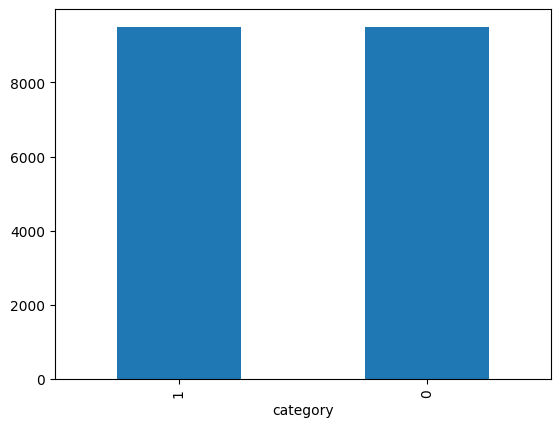

In [4]:
df['category'].value_counts().plot(kind='bar')

In [6]:
df.head()

,review,sentiment,category
0,I first saw Jake Gyllenhaal in Jarhead (2005) ...,positive,1
1,I enjoyed the movie and the story immensely! I...,positive,1
2,I had a hard time sitting through this. Every ...,negative,0
3,It's hard to imagine that anyone could find th...,negative,0
4,This is one military drama I like a lot! Tom B...,positive,1


In [8]:
# Do the train test split of the data with 80% training and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(df['review'], df['category'], test_size=0.2, random_state=42)

In [9]:
# create  a pipeline with CountVectorizer and RandomForestClassifier
pipeline_rf = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('classifier', RandomForestClassifier())
])

# fit the pipeline on the training data
pipeline_rf.fit(X_train, y_train)

# predict the labels for the test data
y_pred_rf = pipeline_rf.predict(X_test)
# print the classification report and confusion matrix for the Random Forest Classifier
print("Classification Report for Random Forest Classifier:")
print(classification_report(y_test, y_pred_rf))

Classification Report for Random Forest Classifier:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1864
           1       0.86      0.85      0.85      1936

    accuracy                           0.85      3800
   macro avg       0.85      0.85      0.85      3800
weighted avg       0.85      0.85      0.85      3800



In [10]:
# create a pipeline with CountVectorizer and KNeighborsClassifier
pipeline_knn = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('classifier', KNeighborsClassifier())
])

# fit the pipeline on the training data
pipeline_knn.fit(X_train, y_train)

# predict the labels for the test data
y_pred_knn = pipeline_knn.predict(X_test)

# print the classification report and confusion matrix for the KNeighbors Classifier
print("Classification Report for KNeighbors Classifier:")
print(classification_report(y_test, y_pred_knn))

Classification Report for KNeighbors Classifier:
              precision    recall  f1-score   support

           0       0.65      0.55      0.60      1864
           1       0.62      0.71      0.67      1936

    accuracy                           0.63      3800
   macro avg       0.64      0.63      0.63      3800
weighted avg       0.64      0.63      0.63      3800



In [11]:
# Using Multinomial Naive Bayes Classifier
pipeline_nb = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('classifier', MultinomialNB())
])

# fit the pipeline on the training data
pipeline_nb.fit(X_train, y_train)

# predict the labels for the test data
y_pred_nb = pipeline_nb.predict(X_test)

# print the classification report and confusion matrix for the Multinomial Naive Bayes Classifier
print("Classification Report for Multinomial Naive Bayes Classifier:")
print(classification_report(y_test, y_pred_nb))

Classification Report for Multinomial Naive Bayes Classifier:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1864
           1       0.87      0.81      0.84      1936

    accuracy                           0.84      3800
   macro avg       0.85      0.84      0.84      3800
weighted avg       0.85      0.84      0.84      3800



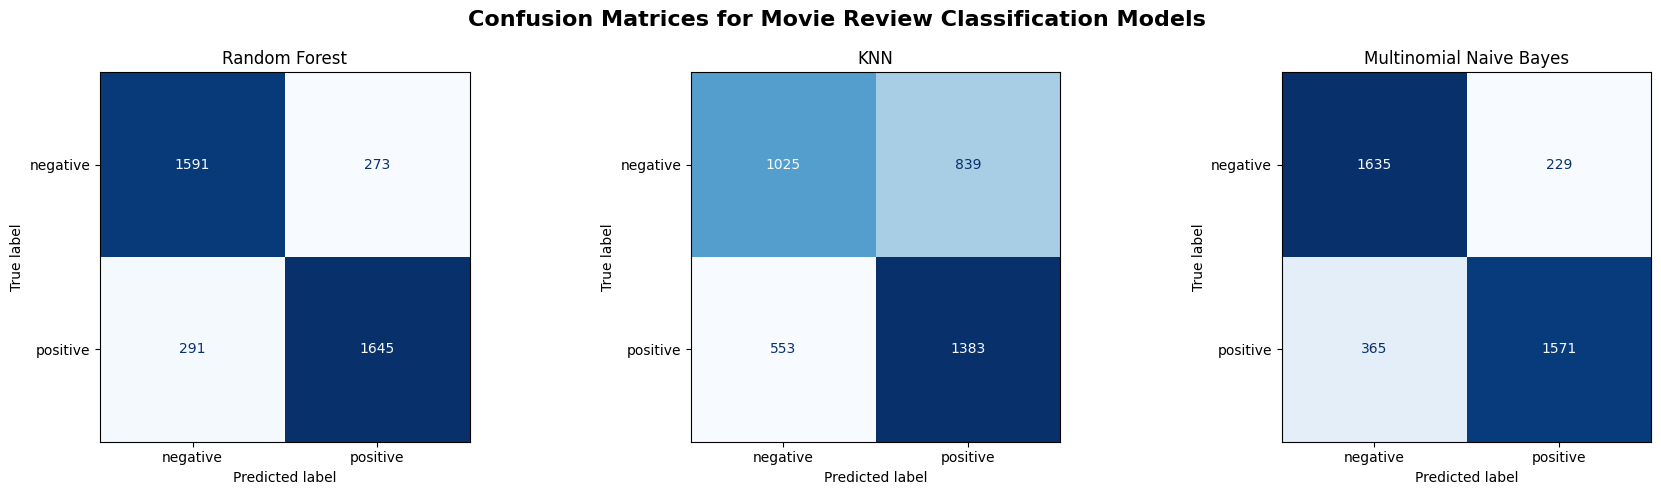

Model Comparison Summary:
                  Model  Accuracy  Precision (weighted)  Recall (weighted)  F1-score (weighted)
          Random Forest    0.8516                0.8516             0.8516               0.8516
Multinomial Naive Bayes    0.8437                0.8457             0.8437               0.8436
                    KNN    0.6337                0.6357             0.6337               0.6311

Best overall model by weighted F1-score: Random Forest (0.8516)
The confusion matrices show where each model makes false positives and false negatives, while the summary table gives a quick comparison of overall performance.


In [13]:
# Compare all models with confusion matrices and a compact summary report
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
models = {
    'Random Forest': y_pred_rf,
    'KNN': y_pred_knn,
    'Multinomial Naive Bayes': y_pred_nb
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices for Movie Review Classification Models', fontsize=16, fontweight='bold')

summary_rows = []
for ax, (model_name, predictions) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        display_labels=['negative', 'positive'],
        cmap='Blues',
        colorbar=False,
        ax=ax
    )
    ax.set_title(model_name)

    report = classification_report(y_test, predictions, output_dict=True)
    summary_rows.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision (weighted)': report['weighted avg']['precision'],
        'Recall (weighted)': report['weighted avg']['recall'],
        'F1-score (weighted)': report['weighted avg']['f1-score']
    })

plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(summary_rows).sort_values(by='F1-score (weighted)', ascending=False)
print('Model Comparison Summary:')
print(summary_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

best_model = summary_df.iloc[0]
print()
print(f'Best overall model by weighted F1-score: {best_model["Model"]} ({best_model["F1-score (weighted)"]:.4f})')
print('The confusion matrices show where each model makes false positives and false negatives, while the summary table gives a quick comparison of overall performance.')

## Model Report

The three classifiers were evaluated on the same test split using confusion matrices and weighted classification metrics.

- Random Forest performed best overall with a weighted F1-score of 0.8516 and accuracy of 0.8516.
- Multinomial Naive Bayes was a close second with a weighted F1-score of 0.8436 and accuracy of 0.8437.
- KNN performed noticeably worse than the other two models, with a weighted F1-score of 0.6311 and accuracy of 0.6337.

### Interpretation

The confusion matrices show that Random Forest and Multinomial Naive Bayes both classify positive and negative reviews well, with fewer false positives and false negatives than KNN. KNN makes far more mistakes on both classes, which suggests it is not a strong fit for this bag-of-words sentiment task.

### Conclusion

For this dataset, Random Forest is the strongest choice among the tested models. If the goal is a simple and reliable baseline, Multinomial Naive Bayes is also a strong option because it performs nearly as well while remaining very efficient.